# Anomaly Detection using CNN Autoencoder

### Loading Data from Google Drive

In [1]:
!unzip -o Dataset/fruits_anomaly_detection.zip

Archive:  Dataset/fruits_anomaly_detection.zip
  inflating: fruits_anomaly_detection/apples_train/Apple Red Yellow 1/r_192_100.jpg  
  inflating: fruits_anomaly_detection/onions/Onion Red/167_100.jpg  
  inflating: fruits_anomaly_detection/apples_train/Apple Red Yellow 1/r_123_100.jpg  
  inflating: fruits_anomaly_detection/apples_train/Apple Red Yellow 1/263_100.jpg  
  inflating: fruits_anomaly_detection/apples_train/Apple Red Yellow 1/130_100.jpg  
  inflating: fruits_anomaly_detection/apples_train/Apple Red Yellow 1/r_247_100.jpg  
  inflating: fruits_anomaly_detection/apples_train/Apple Red Yellow 1/r_213_100.jpg  
  inflating: fruits_anomaly_detection/apples_train/Apple Red Yellow 1/211_100.jpg  
  inflating: fruits_anomaly_detection/apples_train/Apple Red Yellow 1/r_303_100.jpg  
  inflating: fruits_anomaly_detection/apples_train/Apple Red Yellow 1/112_100.jpg  
  inflating: fruits_anomaly_detection/onions/Onion Red/181_100.jpg  
  inflating: fruits_anomaly_detection/apples_trai

### Import

In [1]:
import os
import keras
from keras.models import Sequential
from keras.layers import Dense, Activation, Flatten, Input, Conv2D, MaxPooling2D, UpSampling2D, Rescaling, Reshape
import matplotlib.pyplot as plt
from keras import backend as K
import numpy as np
from tensorflow.keras.utils import array_to_img, img_to_array, load_img, image_dataset_from_directory
from PIL import Image, ImageChops
import random

2025-04-29 17:12:34.251786: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-29 17:12:34.253789: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-29 17:12:34.259659: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745939554.269444   25667 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745939554.272446   25667 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1745939554.280594   25667 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

### Create generators for training, validation and testing

- Read data from folders using ImageDataGenerator
- Generate data from the images in a folder, allows use of datasets that do not fit in main memory all at once
- Image resizing is done by the generator so a folder with any sized-images can be used

The named directory must contain one or more subfolders, path should look like `apples_train/apple_class1/img1.jpg`


- Generate batches of tensor image data with real-time data augmentation.
- A DirectoryIterator yielding tuples of (x, y) where x is a numpy array containing a batch of images with shape (batch_size, *target_size, channels) and y is a numpy array of corresponding labels.

---
`flow_from_directory(directory)`

**Description**: Takes the path to a directory, and generates batches of augmented/normalized data (Yields batches indefinitely, in an infinite loop.)

In [2]:
seed = 91166
batch_size = 85
normalization_layer = Rescaling(1./255)

# Dataset definition
train_dataset, validation_dataset = image_dataset_from_directory(
    directory="fruits_anomaly_detection/apples_train",
    batch_size=batch_size,
    validation_split=.2,
    subset="both",
    seed=seed,
    image_size=(96,96),
    data_format="channels_last",
)
test_dataset = image_dataset_from_directory(
    directory="fruits_anomaly_detection/apples_test/",
    batch_size=batch_size,
    image_size=(96,96),
    seed=seed,
    data_format="channels_last",
)
anomaly_dataset = image_dataset_from_directory(
    directory="fruits_anomaly_detection/eggplant",
    batch_size=batch_size,
    image_size=(96,96),
    seed=seed,
    data_format="channels_last",
)

# Normalization
_norm_function = lambda x, y: (normalization_layer(x), y)
train_dataset_norm = train_dataset.map(_norm_function)
validation_dataset_norm = validation_dataset.map(_norm_function)
test_dataset_norm = test_dataset.map(_norm_function)
anomaly_dataset_norm = anomaly_dataset.map(_norm_function)

# X as label (X = Y)
_replaceY_function = lambda x, y: (x, x)
train_dataset_norm = train_dataset_norm.map(_replaceY_function)
validation_dataset_norm = validation_dataset_norm.map(_replaceY_function)
test_dataset_norm = test_dataset_norm.map(_replaceY_function)
anomaly_dataset_norm = anomaly_dataset_norm.map(_replaceY_function)


Found 6416 files belonging to 13 classes.
Using 5133 files for training.
Using 1283 files for validation.
Found 2138 files belonging to 13 classes.
Found 468 files belonging to 3 classes.


E0000 00:00:1745939556.395957   25667 cuda_executor.cc:1228] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1745939556.399235   25667 gpu_device.cc:2341] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


<_MapDataset element_spec=(TensorSpec(shape=(None, 96, 96, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 96, 96, 3), dtype=tf.float32, name=None))>
X: (85, 96, 96, 3) Y: (85, 96, 96, 3)
X: tf.Tensor(
[[[1. 1. 1.]
  [1. 1. 1.]
  [1. 1. 1.]
  ...
  [1. 1. 1.]
  [1. 1. 1.]
  [1. 1. 1.]]

 [[1. 1. 1.]
  [1. 1. 1.]
  [1. 1. 1.]
  ...
  [1. 1. 1.]
  [1. 1. 1.]
  [1. 1. 1.]]

 [[1. 1. 1.]
  [1. 1. 1.]
  [1. 1. 1.]
  ...
  [1. 1. 1.]
  [1. 1. 1.]
  [1. 1. 1.]]

 ...

 [[1. 1. 1.]
  [1. 1. 1.]
  [1. 1. 1.]
  ...
  [1. 1. 1.]
  [1. 1. 1.]
  [1. 1. 1.]]

 [[1. 1. 1.]
  [1. 1. 1.]
  [1. 1. 1.]
  ...
  [1. 1. 1.]
  [1. 1. 1.]
  [1. 1. 1.]]

 [[1. 1. 1.]
  [1. 1. 1.]
  [1. 1. 1.]
  ...
  [1. 1. 1.]
  [1. 1. 1.]
  [1. 1. 1.]]], shape=(96, 96, 3), dtype=float32)
Y: tf.Tensor(
[[[1. 1. 1.]
  [1. 1. 1.]
  [1. 1. 1.]
  ...
  [1. 1. 1.]
  [1. 1. 1.]
  [1. 1. 1.]]

 [[1. 1. 1.]
  [1. 1. 1.]
  [1. 1. 1.]
  ...
  [1. 1. 1.]
  [1. 1. 1.]
  [1. 1. 1.]]

 [[1. 1. 1.]
  [1. 1. 1.]
  [1. 1. 1.]
  ...


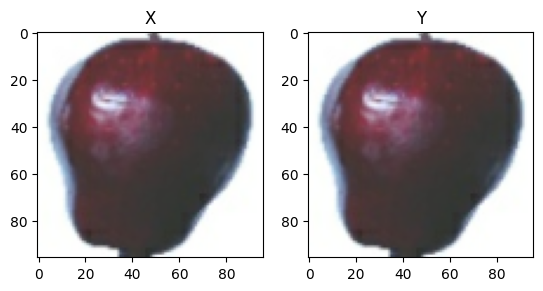

<_MapDataset element_spec=(TensorSpec(shape=(None, 96, 96, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 96, 96, 3), dtype=tf.float32, name=None))>
X: (85, 96, 96, 3) Y: (85, 96, 96, 3)
X: tf.Tensor(
[[[1.        1.        1.       ]
  [1.        1.        1.       ]
  [1.        1.        1.       ]
  ...
  [1.        1.        1.       ]
  [1.        1.        1.       ]
  [1.        1.        1.       ]]

 [[1.        1.        1.       ]
  [1.        1.        1.       ]
  [1.        1.        1.       ]
  ...
  [1.        1.        1.       ]
  [1.        1.        1.       ]
  [1.        1.        1.       ]]

 [[1.        1.        1.       ]
  [1.        1.        1.       ]
  [1.        1.        1.       ]
  ...
  [1.        1.        1.       ]
  [1.        1.        1.       ]
  [1.        1.        1.       ]]

 ...

 [[0.9995915 1.        1.       ]
  [0.9995915 1.        1.       ]
  [0.9996341 1.        1.       ]
  ...
  [1.        1.        1.       ]
  [1

2025-04-29 17:12:36.704102: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


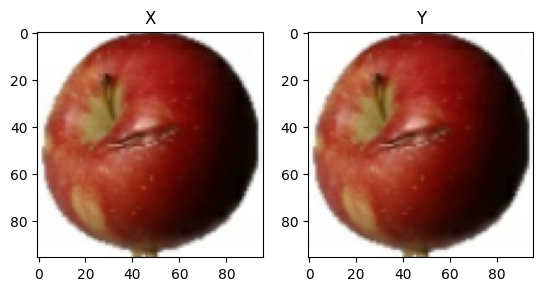

2025-04-29 17:12:36.835582: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


<_MapDataset element_spec=(TensorSpec(shape=(None, 96, 96, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 96, 96, 3), dtype=tf.float32, name=None))>
X: (85, 96, 96, 3) Y: (85, 96, 96, 3)
X: tf.Tensor(
[[[0.9922386  0.9922386  0.99207526]
  [0.99583846 0.9963236  0.9882404 ]
  [0.9922301  1.         0.98749155]
  ...
  [1.         1.         1.        ]
  [1.         1.         1.        ]
  [1.         1.         1.        ]]

 [[0.9922386  0.9927237  0.99184036]
  [0.9960785  0.99655336 0.9887102 ]
  [0.99566996 1.         0.9909825 ]
  ...
  [1.         1.         1.        ]
  [1.         1.         1.        ]
  [1.         1.         1.        ]]

 [[0.9922386  1.         0.988317  ]
  [0.9960785  1.         0.9921569 ]
  [0.99566996 1.         0.9917484 ]
  ...
  [1.         1.         0.99991494]
  [1.         1.         1.        ]
  [1.         1.         1.        ]]

 ...

 [[1.         1.         1.        ]
  [1.         1.         1.        ]
  [1.         1.  

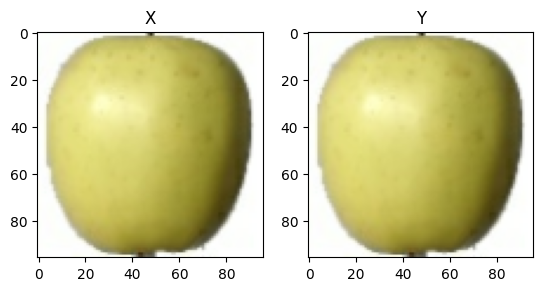

<_MapDataset element_spec=(TensorSpec(shape=(None, 96, 96, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 96, 96, 3), dtype=tf.float32, name=None))>
X: (85, 96, 96, 3) Y: (85, 96, 96, 3)
X: tf.Tensor(
[[[1. 1. 1.]
  [1. 1. 1.]
  [1. 1. 1.]
  ...
  [1. 1. 1.]
  [1. 1. 1.]
  [1. 1. 1.]]

 [[1. 1. 1.]
  [1. 1. 1.]
  [1. 1. 1.]
  ...
  [1. 1. 1.]
  [1. 1. 1.]
  [1. 1. 1.]]

 [[1. 1. 1.]
  [1. 1. 1.]
  [1. 1. 1.]
  ...
  [1. 1. 1.]
  [1. 1. 1.]
  [1. 1. 1.]]

 ...

 [[1. 1. 1.]
  [1. 1. 1.]
  [1. 1. 1.]
  ...
  [1. 1. 1.]
  [1. 1. 1.]
  [1. 1. 1.]]

 [[1. 1. 1.]
  [1. 1. 1.]
  [1. 1. 1.]
  ...
  [1. 1. 1.]
  [1. 1. 1.]
  [1. 1. 1.]]

 [[1. 1. 1.]
  [1. 1. 1.]
  [1. 1. 1.]
  ...
  [1. 1. 1.]
  [1. 1. 1.]
  [1. 1. 1.]]], shape=(96, 96, 3), dtype=float32)
Y: tf.Tensor(
[[[1. 1. 1.]
  [1. 1. 1.]
  [1. 1. 1.]
  ...
  [1. 1. 1.]
  [1. 1. 1.]
  [1. 1. 1.]]

 [[1. 1. 1.]
  [1. 1. 1.]
  [1. 1. 1.]
  ...
  [1. 1. 1.]
  [1. 1. 1.]
  [1. 1. 1.]]

 [[1. 1. 1.]
  [1. 1. 1.]
  [1. 1. 1.]
  ...


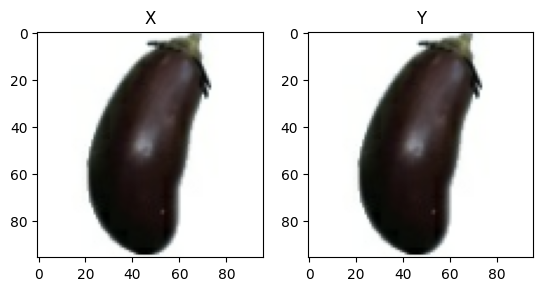

2025-04-29 17:12:37.087330: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [3]:
for dataset in [train_dataset_norm, validation_dataset_norm, test_dataset_norm, anomaly_dataset_norm]:
    print(dataset)
    for x, y in dataset.take(1):
        print(f"X: {x.shape} Y: {y.shape}")
        print("X:", x[0])
        print("Y:", y[0])

        fig, axs = plt.subplots(1,2) 
        axs[0].imshow(x[0])
        axs[1].imshow(y[0])
        
        axs[0].set_title("X")
        axs[1].set_title("Y")
        plt.show()

## **Autoencoder Architecture**

As we have seen in the case of MLP Autoencoder, we build a structure composed by an **Encoder**, that able to reduce the dimensions of our data (extract latent fetaures), and a **Decoder**, that is able to restore the original dimensions.

The output has to have the same structure of the input, the objective is to learn a model able to reconstruct well (producing small reconstruction error) data coming from the same distribution of the training data.

Different data (for example anomalies) should produce higher reconstruction error.

In order to inncrease the data size in the Decoder part we can use the class
**`UpSampling2D`**  https://keras.io/api/layers/reshaping_layers/up_sampling2d/


In [4]:
# Define the convolutional autoencoder model

# input shape must be the same size as the images that will be fed into it by the generators
# The output layer must be the same dimensions as the original image
model = Sequential()
#-------------------------

#encoder
model.add(Conv2D(16, (3, 3), padding='same',activation='relu', input_shape=(96, 96, 3)))
model.add(MaxPooling2D(pool_size=(4,4), padding='same')) # using pool_size (4,4) makes the layer 4x smaller in height and width

model.add(Conv2D(8, (3, 3),activation='relu',  padding='same'))
model.add(MaxPooling2D(pool_size=(4,4), padding='same'))

model.add(Conv2D(3, (3, 3),activation='relu',  padding='same'))
model.add(MaxPooling2D(pool_size=(2,2), padding='same'))

#decoder
model.add(Conv2D(3, (3,3 ), activation = "relu", padding = "same"))
model.add(UpSampling2D((2,2)))

model.add(Conv2D(8, (3, 3), activation = "relu", padding = "same"))
model.add(UpSampling2D((4, 4)))

model.add(Conv2D(16, (3, 3), activation ="relu", padding = "same"))
model.add(UpSampling2D((4,4))) #96x96x 16-> 3 = rgb

model.add(Conv2D(3, (3, 3), activation='sigmoid', padding='same')) #96x96x3
#-------------------------

model.summary()

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')
# MAE can compute the difference between the image in input and the one produced in output (the reconstructed one)

/home/ncvescera/Documents/UniPG/PhD/tutor/lezioni/Machine_Learning-Lab/07_Anomaly_Detection/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 96, 96, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 6, 6, 3)        │           219 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 3)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 3, 3, 3)        │            84 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 6, 6, 3)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 6, 6, 8)        │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 24, 24, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 96, 96, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 96, 96, 3)      │           435 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,738 (14.60 KB)

 Trainable params: 3,738 (14.60 KB)

 Non-trainable params: 0 (0.00 B)

/home/ncvescera/Documents/UniPG/PhD/tutor/lezioni/Machine_Learning-Lab/07_Anomaly_Detection/.venv/lib/python3.12/site-packages/visualkeras/layered.py:86: UserWarning: The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.
  warnings.warn("The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.")
/home/ncvescera/Documents/UniPG/PhD/tutor/lezioni/Machine_Learning-Lab/07_Anomaly_Detection/.venv/lib/python3.12/site-packages/visualkeras/layered.py:86: UserWarning: The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.
  warnings.warn("The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.")


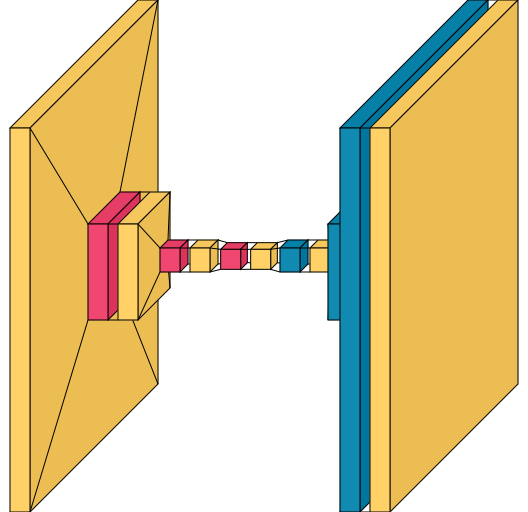

feh WARNING: /tmp/.X0-lock - No Imlib2 loader for that file format
feh WARNING: /tmp/.org.chromium.Chromium.vM5qg0 - No Imlib2 loader for that file format
feh WARNING: /tmp/__autograph_generated_file2lg6zr80.py - No Imlib2 loader for that file format
feh WARNING: /tmp/__autograph_generated_file8lg799v0.py - No Imlib2 loader for that file format
feh WARNING: /tmp/__autograph_generated_fileekxc2u2j.py - No Imlib2 loader for that file format
feh WARNING: /tmp/__autograph_generated_filef8ax2j96.py - No Imlib2 loader for that file format
feh WARNING: /tmp/__autograph_generated_filefhk5e_4d.py - No Imlib2 loader for that file format
feh WARNING: /tmp/__autograph_generated_filei0ua63ii.py - No Imlib2 loader for that file format
feh WARNING: /tmp/__autograph_generated_filern64g4kt.py - No Imlib2 loader for that file format
feh WARNING: /tmp/__autograph_generated_filewhocn9tk.py - No Imlib2 loader for that file format
feh WARNING: /tmp/qtsingleapp-flames-ed0b-3e8-lockfile - Invalid image file


In [6]:
import visualkeras

visualkeras.layered_view(model).show() # display using your system viewer
visualkeras.layered_view(model, to_file='output.png') # write to disk

In [6]:
# Define the convolutional autoencoder model

# input shape must be the same size as the images that will be fed into it by the generators
# The output layer must be the same dimensions as the original image
model_MLP = Sequential()
#-------------------------
in_features = 96*96*3
#encoder
model_MLP.add(Input(shape=(96, 96, 3)))
model_MLP.add(Flatten())
model_MLP.add(Dense(in_features//4, activation="relu"))
model_MLP.add(Dense(in_features//4**2, activation="relu"))
model_MLP.add(Dense(in_features//4**3, activation="relu"))
model_MLP.add(Dense(in_features//4**4, activation="relu"))
model_MLP.add(Dense(in_features//4**4, activation="relu"))
model_MLP.add(Dense(in_features//4**3, activation="relu"))
model_MLP.add(Dense(in_features//4**2, activation="relu"))
model_MLP.add(Dense(in_features//4, activation="relu"))
model_MLP.add(Dense(in_features, activation="sigmoid"))
model_MLP.add(Reshape((96, 96,3)))

#-------------------------

model_MLP.summary()

# Compile the model
model_MLP.compile(optimizer='adam', loss='mean_squared_error')
# MAE can compute the difference between the image in input and the one produced in output (the reconstructed one)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 27648)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6912)           │   191,109,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1728)           │    11,945,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 432)            │       746,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 108)            │        46,764 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 108)            │        11,772 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 432)            │        47,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1728)           │       748,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 6912)           │    11,950,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 27648)          │   191,130,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 96, 96, 3)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407,737,800 (1.52 GB)

 Trainable params: 407,737,800 (1.52 GB)

 Non-trainable params: 0 (0.00 B)

### **Training**

Define `steps_per_epoch`:
- Is the Total number of steps (batches of samples) to yield from generator
- before declaring one epoch finished and starting the next epoch.
- It should typically be equal to `ceil(num_samples / batch_size)`.

EarlyStopping callback in combination with ModelCheckpoint https://keras.io/api/callbacks/


In [7]:
# Define model name
model_filepath = 'image_anomaly_ae.keras'
model_MLP_filepath = 'MLP_anomaly_ae.keras'

In [8]:
# Training the model

# Early stopping (stops training when validation doesn't improve for {patience} epochs)
es = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    mode='min',
    verbose=1,
    patience=30,
    )

# Saves the best version of the model to disk (as measured on the validation data set)
save_best = keras.callbacks.ModelCheckpoint(
    model_MLP_filepath,
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1,
    )

history = model_MLP.fit(
    train_dataset_norm,
    epochs=50,
    validation_data=validation_dataset_norm,
    callbacks=[es, save_best],
    )

Epoch 1/50
15/61 ━━━━━━━━━━━━━━━━━━━━ 1:33 2s/step - loss: 0.0940

KeyboardInterrupt: 

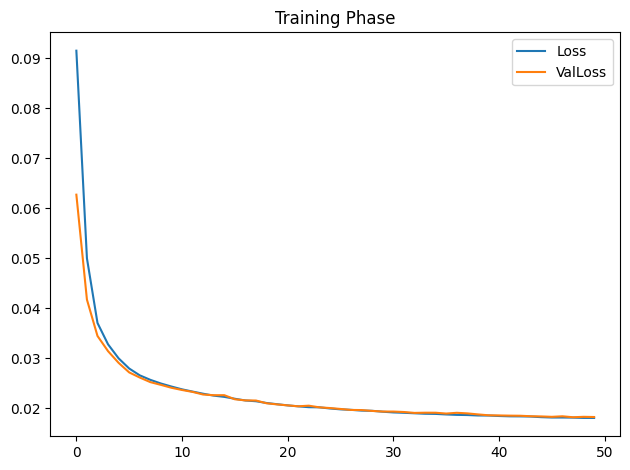

In [8]:
plt.plot(history.history['loss'], label="Loss")
plt.plot(history.history['val_loss'], label="ValLoss")
plt.legend()
plt.title("Training Phase")
plt.tight_layout()
plt.show()

Training continues after improvement stops for the number of epochs equivalent to the 'patience' hyper-parameter

In [9]:
# To get back the model that performed best on the validation set we load the checkpointed model from disk:
model = keras.models.load_model(model_filepath)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 96, 96, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 6, 6, 3)        │           219 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 3)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 3, 3, 3)        │            84 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 6, 6, 3)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 6, 6, 8)        │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 24, 24, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 96, 96, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 96, 96, 3)      │           435 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,216 (43.82 KB)

 Trainable params: 3,738 (14.60 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 7,478 (29.21 KB)

Test the model by viewing a sample of original and reconstructed images.

A `DirectoryIterator` yielding tuples of `(x, y)` where `x` is a numpy array containing a batch of images with shape `(batch_size, *target_size, channels)` and `y` is a numpy array of corresponding labels.

### Testing

In [10]:
def _plot_original_vs_predicted(dataset, title=""):
    # take 1 batch
    for x, _ in dataset.take(1):
        # use juste first 4 images as model input
        predicted = model.predict(x[:4])
        print(predicted.shape)
        
        # plot Original vs Predicted
        fig, axs = plt.subplots(4, 2, figsize=(5,8))
        for i in range(4):
            axs[i][0].imshow(x[i])
            axs[i][1].imshow(predicted[i])
        
        axs[0][0].set_title("Original")
        axs[0][1].set_title("Predicted")
        fig.suptitle(title)

        plt.tight_layout()
        plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
(4, 96, 96, 3)


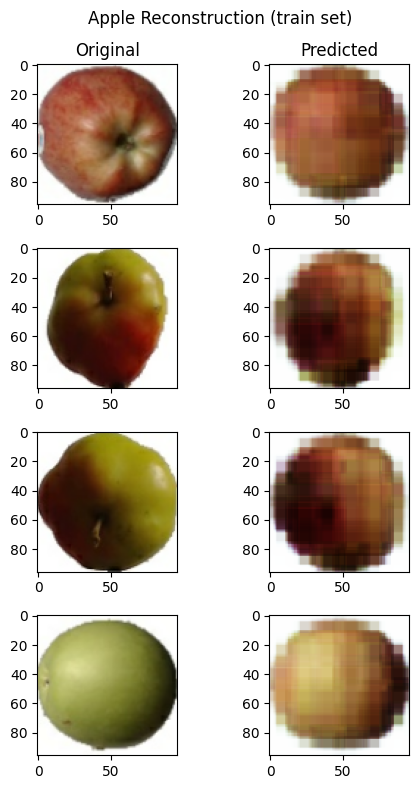

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
(4, 96, 96, 3)


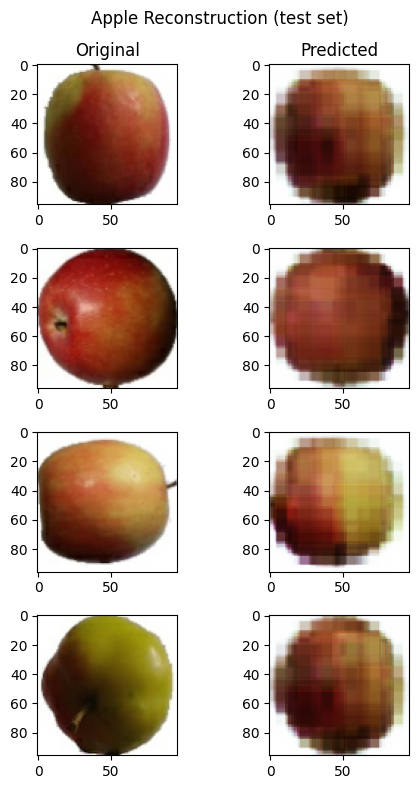

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
(4, 96, 96, 3)


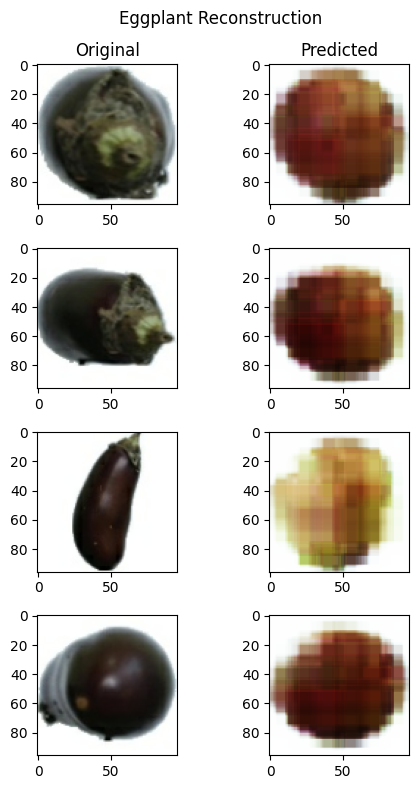

In [11]:
_plot_original_vs_predicted(train_dataset_norm, title="Apple Reconstruction (train set)")
_plot_original_vs_predicted(test_dataset_norm, title="Apple Reconstruction (test set)")
_plot_original_vs_predicted(anomaly_dataset_norm, title="Eggplant Reconstruction")

### **Evaluation**

In [12]:
# We want the difference in error between the testing set (normal) images
# and anomalous images to be as high as possible
train_eval = model.evaluate(train_dataset_norm)
test_eval = model.evaluate(test_dataset_norm)
anomaly_eval = model.evaluate(anomaly_dataset_norm)

print(f"Error on train set:{train_eval:.3f}")
print(f"Error on test set:{test_eval:.3f}")
print(f"Error on anomaly set:{anomaly_eval:.3f}")
print(f"Difference: {abs(test_eval - anomaly_eval):.3f}")

61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0179
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0187
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0678
Error on train set:0.018
Error on test set:0.019
Error on anomaly set:0.067
Difference: 0.049


#### **Analysis of the reconstruction errors**

In [13]:
def compute_plot_rec_error(dataset, plot=True, title="", color="tab:green"):
    r_errors = []
    _mse = lambda orig, pred: np.square(orig - pred).mean()

    for batch_x, _ in dataset:
        preds = model.predict(batch_x)
        
        actual_errors = [_mse(batch_x[i], preds[i]) for i in range(len(preds))]
        r_errors.extend(actual_errors)

    if plot:
        plt.scatter(x=range(len(r_errors)), y=sorted(r_errors), s=3.0, c=color)
        plt.title(title)
        plt.tight_layout()
        plt.show()
    
    return r_errors

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
3/3 ━━━━━━━

2025-04-29 12:27:47.047858: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


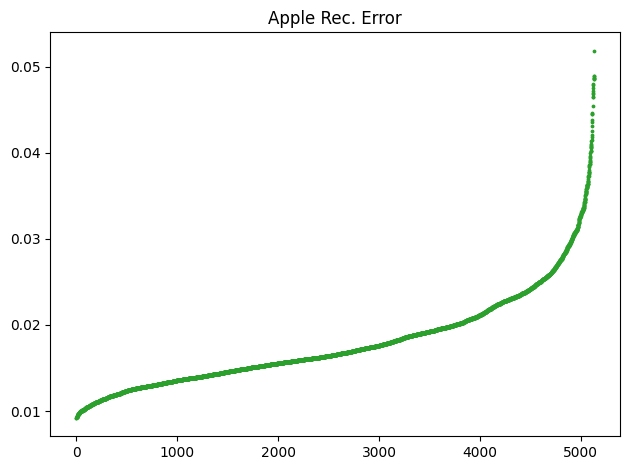

In [14]:
apple_rec_errors = compute_plot_rec_error(train_dataset_norm, title="Apple Rec. Error", color="tab:green")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


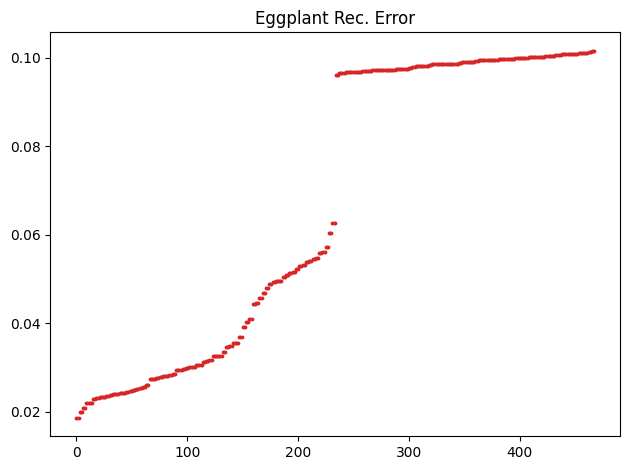

In [15]:
eggplant_rec_errors = compute_plot_rec_error(anomaly_dataset_norm, title="Eggplant Rec. Error", color="tab:red")

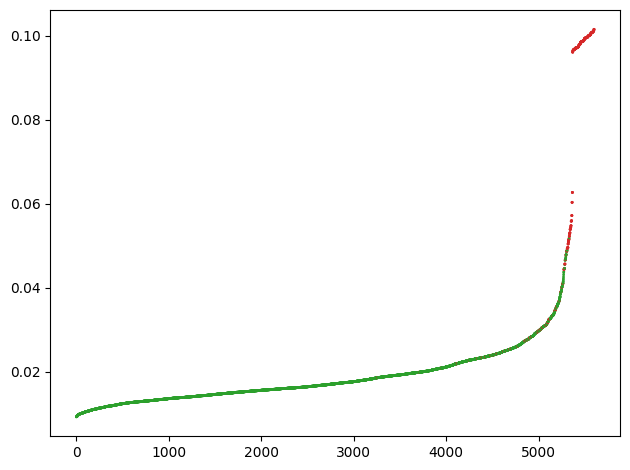

In [16]:
# Combine them into a single plot
all_rec_errs = tuple(zip(apple_rec_errors, ["tab:green"]*len(apple_rec_errors))) + tuple(zip(eggplant_rec_errors, ["tab:red"]*len(eggplant_rec_errors)))
all_rec_errs = sorted(all_rec_errs, key=lambda x: x[0])

plt.scatter(
    x=range(len(all_rec_errs)),
    y=[x for x, _ in all_rec_errs],
    c=[y for _, y in all_rec_errs],
    s=1.0,
    )
plt.tight_layout()
plt.show()

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


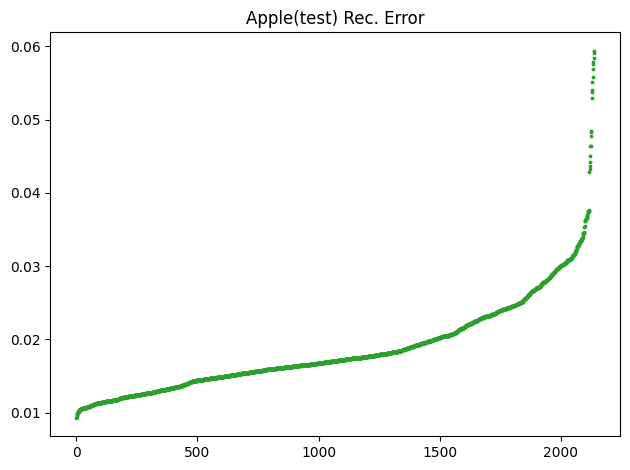

In [17]:
appletest_rec_errors = compute_plot_rec_error(test_dataset_norm, title="Apple(test) Rec. Error", color="tab:green")

#### **Count anomalies on datasets given a threshold**

In [18]:
def count_anomalies(rec_errors, threshold, name=""):
    # Anomaly detection on apple_test samples
    count_anomaly = 0

    # in this case count_anomaly represents the FP (apples that are classified as anomalies)
    count_anomaly = sum(i > threshold for i in rec_errors)

    print(f"{name} anomaly {count_anomaly} over a total of {len(rec_errors)} {name}")
    print(f"{(count_anomaly/(len(rec_errors)) * 100):.2f} %")

    return count_anomaly

In [19]:
threshold = 0.04

In [20]:
# Anomaly detection on apple_train samples
apple_count_anomaly = count_anomalies(apple_rec_errors, threshold, name="apple")

apple anomaly 36 over a total of 5133 apple
0.70 %


In [21]:
# Anomaly detection on apple_test samples
appletest_count_anomaly = count_anomalies(appletest_rec_errors, threshold, name="apple (test)")

apple (test) anomaly 21 over a total of 2138 apple (test)
0.98 %


In [22]:
# Count anomalies on eggplants
#anomaly detection in the eggplant samples
eggplant_count_anomaly = count_anomalies(eggplant_rec_errors, threshold, name="eggplant")

eggplant anomaly 315 over a total of 468 eggplant
67.31 %


#### **ROC Curve**

In [23]:
import pandas as pd
from sklearn.metrics import auc,roc_curve

In [24]:
# Assign labels
# Create labels for normal and anomaly samples
apple_test_labels =  np.zeros(len(apple_rec_errors))     # normal label = 0
eggplant_test_labels = np.ones(len(eggplant_rec_errors)) # anomaly label = 1

# Put all the labels together
all_labels = np.concatenate((apple_test_labels, eggplant_test_labels))

# Put together the reconstruction errors and Target_scores
all_errors  = apple_rec_errors + eggplant_rec_errors

# Create a dataframe to store all the above information, to have everything together
# This way we can compute some statistics easily
error_df = pd.DataFrame({
        'reconstruction_error': all_errors,
        "true_class": all_labels,
        },)

display(error_df.describe())
display(error_df.head())
display(error_df.tail())

,reconstruction_error,true_class
count,5601.000000,5601.000000
mean,0.022125,0.083557
std,0.017474,0.276746
min,0.009204,0.000000
25%,0.014320,0.000000
50%,0.017107,0.000000
75%,0.022423,0.000000
max,0.101554,1.000000


,reconstruction_error,true_class
0,0.016306,0.0
1,0.017434,0.0
2,0.015238,0.0
3,0.013935,0.0
4,0.011955,0.0


,reconstruction_error,true_class
5596,0.101102,1.0
5597,0.100675,1.0
5598,0.097262,1.0
5599,0.018554,1.0
5600,0.034528,1.0


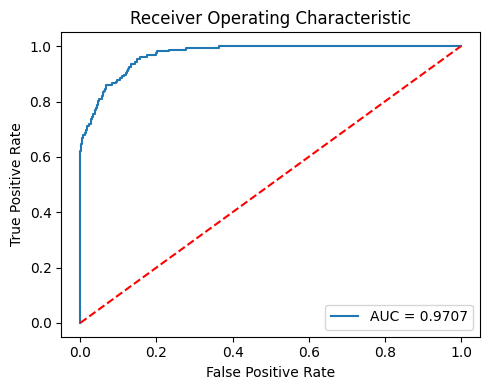

In [25]:
fpr, tpr, thresholds = roc_curve(error_df.true_class, error_df.reconstruction_error)

# AUC
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5,4))
plt.title('Receiver Operating Characteristic')

plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
plt.legend(loc='lower right')
plt.plot([0,1],[0,1],'r--')

plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')

plt.tight_layout()
plt.show()

In [ ]:
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

print("Optimal Threshold:", optimal_threshold)

Threshold ottimale: 0.023331814


In [27]:
_ = count_anomalies(apple_rec_errors, optimal_threshold, name="apple (opt)")
_ = count_anomalies(appletest_rec_errors, optimal_threshold, name="apple (opt)")
_ = count_anomalies(eggplant_rec_errors, optimal_threshold, name="eggplant (opt)")

apple (opt) anomaly 766 over a total of 5133 apple (opt)
14.92 %
apple (opt) anomaly 428 over a total of 2138 apple (opt)
20.02 %
eggplant (opt) anomaly 444 over a total of 468 eggplant (opt)
94.87 %


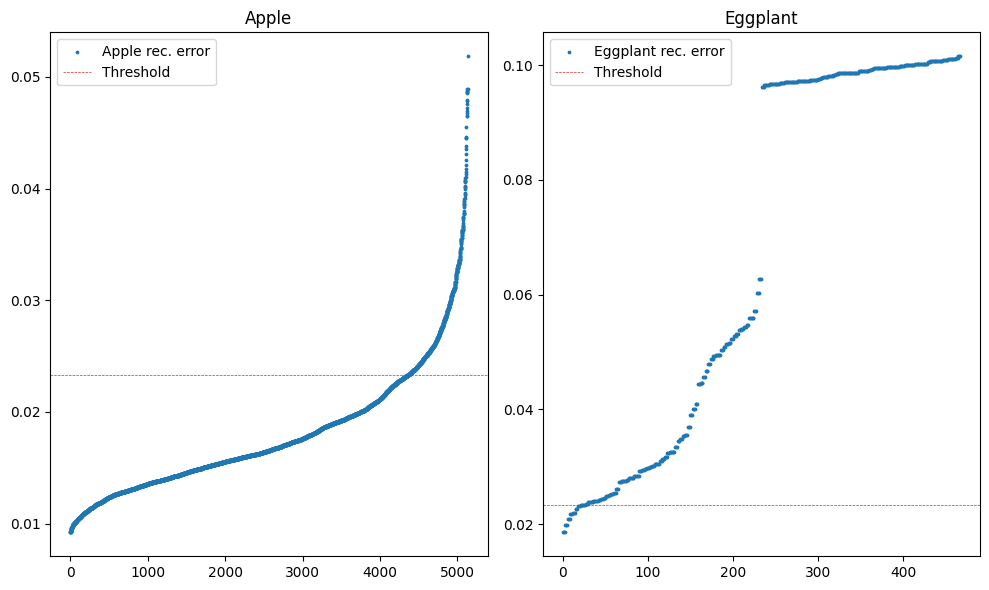

In [28]:
fig, axs = plt.subplots(1, 2, figsize=(10, 6))

for i, (rec_err, title) in enumerate(zip([apple_rec_errors, eggplant_rec_errors], ["Apple", "Eggplant"])):
    axs[i].scatter(x=range(len(rec_err)), y=sorted(rec_err), s=3.0)
    axs[i].axhline(optimal_threshold, color='tab:red', linestyle="--", linewidth=.5)
    axs[i].set_title(title)
    axs[i].legend([f"{title} rec. error", "Threshold"])

plt.tight_layout()
plt.show()